In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.metrics import AUC
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import yfinance as yf

import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')
curr = os.getcwd()
project_root = os.path.abspath(os.path.join(curr, '..', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)
from ai.features import FEATURES
from ai.help_folder.backtest import backtest, production_backtest, filter_signals
from ai.help_folder.help import prepare_data, stage1, stage2, calculate_base_features, optimize_threshold, generate_final_report, download, save_models, save_artifacts_json, print_stage_report

In [2]:
# Параметры
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "AAPL"
START_DATE = "2010-01-01"
END_DATE = "2023-12-31"
INTERVAL = "1d"

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEQUENCE_LENGTH = 20

GRU_UNITS = 32
DENSE_UNITS = 8
DROPOUT_RATE = 0.45 
LEARNING_RATE = 0.00005
BATCH_SIZE = 128
EPOCHS = 100
PATIENCE_ES = 5
PATIENCE_LR = 5

MOVE_THRESHOLD = 0.015
HORIZON = 2

COMMISSION = 0.001
SLIPPAGE = 0.0005
MAX_POSITION_SIZE = 0.1 
MAX_DRAWDOWN = 0.15      


L2_REG = 0.05
LABEL_SMOOTHING = 0.1
TOP_K_PERCENT = 15
SHORT_BASE_TH = 30
LONG_BASE_TH = 70

MODEL_PATH = '../models/model_gru'

In [ ]:

def create_model(input_dim, name='GRU'):
    model = Sequential([
        Input(shape=input_dim),
        Bidirectional(GRU(GRU_UNITS, return_sequences=False, 
                         kernel_regularizer=regularizers.l2(L2_REG),
                         recurrent_regularizer=regularizers.l2(L2_REG))),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        
        Dense(16, activation='relu', kernel_regularizer=regularizers.l2(L2_REG)),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', AUC(name='auc')]
    )
    return model

In [4]:
# ЗАГРУЗКА ДАННЫХ
raw_data, raw_df = download(TICKER, START_DATE, END_DATE, interval=INTERVAL)
print(f"📊 Загружено {len(raw_df)} записей")

spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)
vix = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

print("\n🔧 Подготовка данных...")
df = calculate_base_features(raw_df, spy, vix)
df = df.reset_index(drop=True)

# ПОДГОТОВКА ДАННЫХ
res_prepare_data = prepare_data(
    df, TRAIN_SPLIT, VAL_SPLIT, SEQUENCE_LENGTH,
    move_threshold=MOVE_THRESHOLD, horizon=HORIZON, FEATURES1=FEATURES
)

📊 Загружено 3522 записей

🔧 Подготовка данных...
✅ Создано 34 признаков. Всего строк: 3522
✅ Train: 2444 | Val: 508 | Test: 508


In [5]:
res_stage1 = stage1(
    res_prepare_data['X_train'], 
    res_prepare_data['X_val'], 
    res_prepare_data['X_test'],
    res_prepare_data['y1_train'], 
    res_prepare_data['y1_val'], 
    res_prepare_data['y1_test'],
    res_prepare_data['cw1'],
    create_model=create_model, # Теперь это передается корректно
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES,
    PATIENCE_LR=PATIENCE_LR
)


 STAGE 1: MOVE vs HOLD (Volatility/Activity Filter)
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5188 - auc: 0.5376 - loss: 9.3814 - val_accuracy: 0.3799 - val_auc: 0.5570 - val_loss: 9.2051 - learning_rate: 5.0000e-05
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5127 - auc: 0.5404 - loss: 9.2753 - val_accuracy: 0.3799 - val_auc: 0.5553 - val_loss: 9.1150 - learning_rate: 5.0000e-05
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5164 - auc: 0.5618 - loss: 9.1458 - val_accuracy: 0.3760 - val_auc: 0.5555 - val_loss: 9.0279 - learning_rate: 5.0000e-05
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5090 - auc: 0.5414 - loss: 9.0592 - val_accuracy: 0.3760 - val_auc: 0.5546 - val_loss: 8.9385 - learning_rate: 5.0000e-05
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5205 - auc: 0.5422 - loss: 8.9669 - val_accuracy: 0.3819 - val_auc: 0.5523 - val_loss: 8.8513 - learning_rate: 5.0000e-05
Epoch 6/100

In [6]:
# STAGE 2: UP and DOWN (для GRU)
res_stage2 = stage2(
    X_train=res_prepare_data['X_train'],
    X_val=res_prepare_data['X_val'],
    X_test=res_prepare_data['X_test'],
    y2_train=res_prepare_data['y2_train'],
    y2_val=res_prepare_data['y2_val'],
    y2_test=res_prepare_data['y2_test'],
    mask1_train=res_stage1['mask_train'],
    mask1_val=res_stage1['mask_val'],
    mask1_test=res_stage1['mask_test'],
    create_model=create_model, 
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES
)


 STAGE 2: UP vs DOWN (Directional Model)
Обучение на 1434 сбалансированных примерах (50/50)
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5063 - auc: 0.4992 - loss: 9.5486 - val_accuracy: 0.4416 - val_auc: 0.4378 - val_loss: 9.1799
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4965 - auc: 0.4849 - loss: 9.5066 - val_accuracy: 0.4448 - val_auc: 0.4361 - val_loss: 9.1213
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5112 - auc: 0.4954 - loss: 9.4110 - val_accuracy: 0.4385 - val_auc: 0.4373 - val_loss: 9.0630
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4958 - auc: 0.4943 - loss: 9.3615 - val_accuracy: 0.4322 - val_auc: 0.4351 - val_loss: 9.0052
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5042 - auc: 0.5134 - loss: 9.2647 - val_accuracy: 0.4353 - val_auc: 0.4343 - val_loss: 8.9478
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5049 - auc: 0.4994 - loss: 9.2058 - val_accura

In [7]:
print_stage_report(
    res_prepare_data['y1_test'],
    res_stage1['mask_test'].astype(int), 
    "Stage 1 (MOVE vs HOLD)",
    ['HOLD', 'MOVE']
)

temp_preds_s2 = (res_stage2['probs_full'] >= 0.5).astype(int)

print_stage_report(
    res_prepare_data['y2_test'],
    temp_preds_s2,
    "Stage 2 (UP vs DOWN) - Raw Performance",
    ['DOWN', 'UP']
)


Stage 1 (MOVE vs HOLD):
              precision    recall  f1-score   support

        HOLD       0.84      0.15      0.25       431
        MOVE       0.15      0.84      0.25        77

    accuracy                           0.25       508
   macro avg       0.50      0.50      0.25       508
weighted avg       0.74      0.25      0.25       508


Stage 2 (UP vs DOWN) - Raw Performance:
              precision    recall  f1-score   support

        DOWN       0.49      0.21      0.29       250
          UP       0.51      0.79      0.62       258

    accuracy                           0.50       508
   macro avg       0.50      0.50      0.46       508
weighted avg       0.50      0.50      0.46       508



In [8]:

from ai.help_folder.backtest import get_statistical_signals
y_pred_final = get_statistical_signals(
    res_stage1['probs_test'], 
    res_stage2['probs_full'], 
    top_k_percent=TOP_K_PERCENT,
    short_base_th=SHORT_BASE_TH,
    long_base_th=LONG_BASE_TH
)

print(f"GRU BUY signals: {np.sum(y_pred_final == 1)}")
print(f"GRU SELL signals: {np.sum(y_pred_final == -1)}")

GRU BUY signals: 23
GRU SELL signals: 23


ROC AUC Stage 1: 0.5650
ROC AUC Stage 2: 0.5328


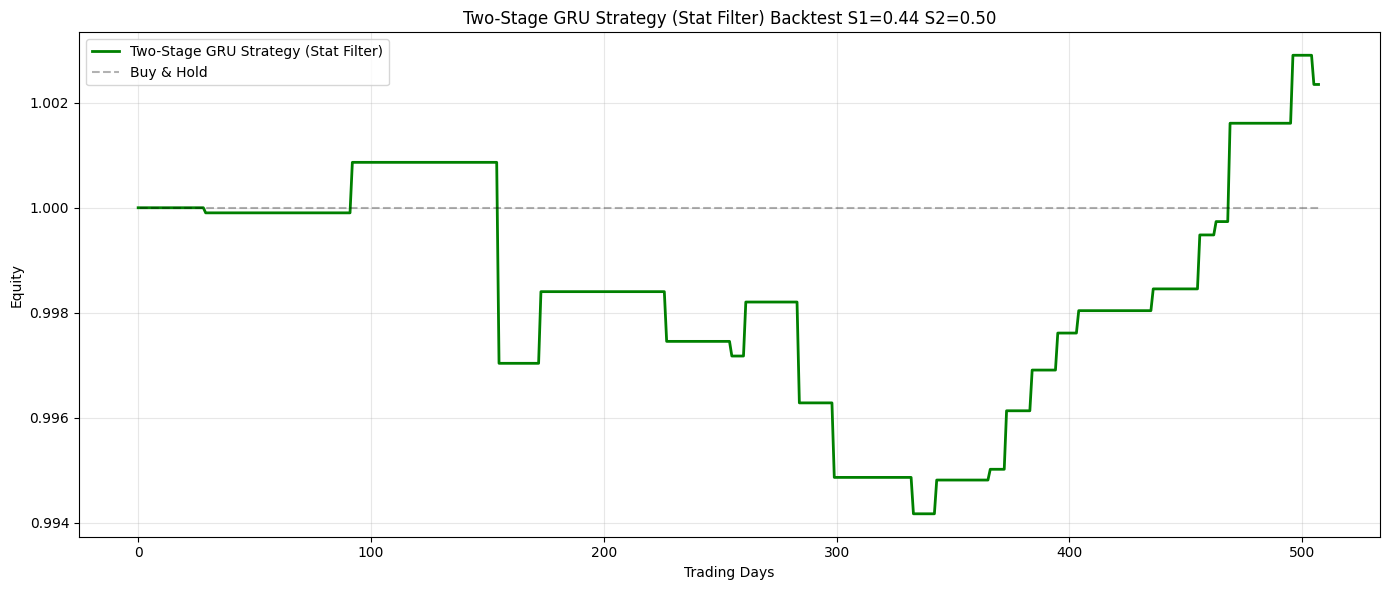

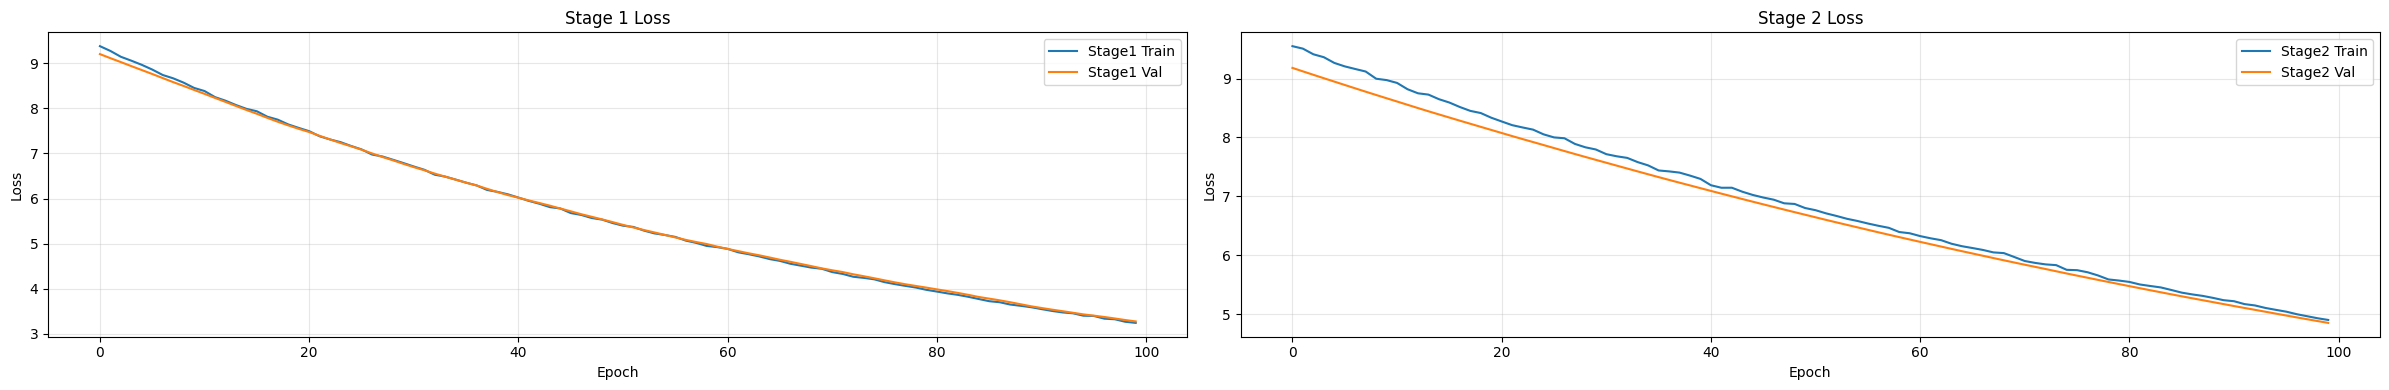

In [9]:
from sklearn.metrics import roc_auc_score

auc_s1 = roc_auc_score(res_prepare_data['y1_test'], res_stage1['probs_test'])
print(f"ROC AUC Stage 1: {auc_s1:.4f}")

mask = res_stage1['mask_test']
y2_true_filtered = res_prepare_data['y2_test'][mask]
valid_idx = ~np.isnan(y2_true_filtered)

if len(y2_true_filtered[valid_idx]) > 0:
    auc_s2 = roc_auc_score(y2_true_filtered[valid_idx], res_stage2['probs_filtered'][valid_idx])
    print(f"ROC AUC Stage 2: {auc_s2:.4f}")
else:
    print("Stage 2 AUC: недостаточно данных для расчета")

results = production_backtest(
    df_test=res_prepare_data['df_test'],
    signals=y_pred_final, # ПЕРЕДАЕМ ГОТОВЫЕ КОМАНДЫ ИЗ ПЕРВОЙ ЯЧЕЙКИ
    commission=COMMISSION,
    slippage=SLIPPAGE,
    max_position_size=MAX_POSITION_SIZE,
    horizon=HORIZON
)

history_stages = [res_stage1['history'], res_stage2['history']]
thresholds = {"S1": res_stage1['threshold'], "S2": 0.5}

backtest(
    results=results,
    history_stages=history_stages,
    strategy_name="Two-Stage GRU Strategy (Stat Filter)",
    thresholds=thresholds,
    save_dir="../models/model_gru"
)


In [10]:

s1_f1 = res_stage1.get('f1_val', 0.0) 
s2_threshold = 0.5 
s2_f1 = 0.0 

params = {
    'threshold_stage1': res_stage1['threshold'],
    'threshold_stage2': s2_threshold,
    'move_threshold': MOVE_THRESHOLD,
    'horizon': HORIZON,
    'commission': COMMISSION,
    'slippage': SLIPPAGE,
    'max_position_size': MAX_POSITION_SIZE,
    'max_drawdown': MAX_DRAWDOWN,
    'sequence_length': SEQUENCE_LENGTH
}

# 2. Подготовка результатов бектеста
# Проверь названия ключей в твоем объекте results (иногда 'sharpe_ratio' вместо 'sharpe')
backtest_results = {
    "total_return": results.get('total_return', 0),
    "sharpe_ratio": results.get('sharpe', results.get('sharpe_ratio', 0)),
    "max_drawdown": results.get('max_drawdown', 0),
    "win_rate": results.get('win_rate', 0),
    "trades": results.get('trades', 0),
    "avg_pnl": results.get('avg_pnl', 0)
}

# 3. Сохранение артефактов
save_artifacts_json(
    base_dir=MODEL_PATH,
    strategy_name="two_stage",
    res_stage1=res_stage1,
    res_stage2=res_stage2,
    FEATURES=FEATURES,
    params=params,
    backtest_results=backtest_results
)

save_models(
    model_stage1=res_stage1['model'],
    model_stage2=res_stage2['model'],
    scaler=res_prepare_data['scaler'],
    params=params,
    base_dir=MODEL_PATH,
    features=FEATURES
)

generate_final_report(
    results=results,
    model_type="two_stage",
    stage1_metrics={
        "threshold": res_stage1['threshold'],
        "f1": s1_f1
    },
    stage2_metrics={
        "threshold": s2_threshold,
        "f1": s2_f1
    },
    ml_metrics={
        "Stage 1 F1": s1_f1,
        "Stage 2 F1": s2_f1
    }
)

✅ JSON summary saved: ../models/model_gru/two_stage/artifacts_summary.json
✅ Model Stage 1 saved: ../models/model_gru/strategy/model_stage1.h5
✅ Model Stage 2 saved: ../models/model_gru/strategy/model_stage2.h5
✅ Scaler, features, and params (WITH features list) saved to ../models/model_gru/strategy

📁 Все артефакты сохранены в ../models/model_gru/strategy

📋 ИТОГОВЫЙ ОТЧЁТ

🎯 Two-Stage Classification:
   Stage 1: MOVE vs HOLD (Threshold=0.44, F1=0.5722)
   Stage 2: UP vs DOWN (Threshold=0.5, F1=0.0000)

Метрики:
   Stage 1 F1: 0.5722
   Stage 2 F1: 0.0000

💰 Production Backtest:
   Total Return: 0.2%
   Sharpe Ratio: 0.28
   Max Drawdown: 0.7%
Trades: 22
   Win Rate: 54.5%
